## Project 02 : K-means

In [11]:
import numpy as np

### K-Means Algorithm: Detailed Steps

In [12]:
def compute_labels(X, centroids):
    """Compute labels.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    centroids: array-like, shape (n_clusters, n_features)
        The estimated centroids.

    Returns
    -------
    labels : array, shape (n_samples,)
        The labels of each sample
    """
    # Q1: Implement K-means
    distances = np.array([
        np.sum((X - centroids[k])**2, axis=1)  # distance² au centroïde k
        for k in range(len(centroids))
    ])  # shape : (K, n)
    
    # Assigner chaque point au centroïde le plus proche
    labels = np.argmin(distances, axis=0)  # shape : (n,)
    return labels


def compute_inertia_centroids(X, labels):
    """Compute inertia and centroids.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    labels : array-like, shape (n_saples,)
        The labels of each sample.

    Returns
    -------
    inertia: float
        The inertia.

    centroids: array-like, shape (n_clusters, n_features)
        The estimated centroids.
    """
    # Q1: Implement K-means
    K = len(np.unique(labels))
    n, d = X.shape
    centroids = np.zeros((K, d))
    inertia = 0.0
    
    for k in range(K):
        # Points appartenant au cluster k
        points_k = X[labels == k]
        
        if len(points_k) > 0:
            centroids[k] = points_k.mean(axis=0)          # nouveau centroïde
            inertia += np.sum((points_k - centroids[k])**2)  # contribution à G
    
    return inertia, centroids


def kmeans(X, n_clusters, max_iter=100, tol=1e-7, random_state=42):
    """Estimate position of centroids and labels.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_clusters: int
        The desired number of clusters.

    max_iter: int, defaults 100.
        Max number of update.

    tol: float, defaults 1e-7.
        The tolerance to check convergence.

    random_state: int, defaults to 42.
        A random number generator instance.

    Returns
    -------
    centroids: array-like, shape (n_clusters, n_features)
        The estimated centroids.

    labels: array-like, shape (n_samples,)
        The estimated labels.

    inertia: float
        The inertia.
    """
    # Q1: Implement K-means
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    
    # Initialisation : choisir K points aléatoirement comme centroïdes
    idx = rng.choice(n, n_clusters, replace=False)
    centroids = X[idx].copy()
    
    inertia = np.inf
    
    for _ in range(max_iter):
        # Étape I : assignation
        labels = compute_labels(X, centroids)
        
        # Étape II : mise à jour
        new_inertia, new_centroids = compute_inertia_centroids(X, labels)
        
        # Critère d'arrêt : l'inertie ne diminue plus
        if abs(inertia - new_inertia) < tol:
            break
        
        inertia = new_inertia
        centroids = new_centroids
    
    return centroids, labels, inertia

In [15]:
if __name__ == '__main__':
    from sklearn.datasets import make_blobs

    # Parameters
    random_state = 0
    n_samples = 1000
    color = 'rgbcmyk'

    # Generate data
    X, y = make_blobs(n_samples=n_samples, random_state=random_state,
                      centers=3)
    centroids, labels, inertia = kmeans(X, n_clusters=3)
    # Q1-Q4 Apply K-means to X


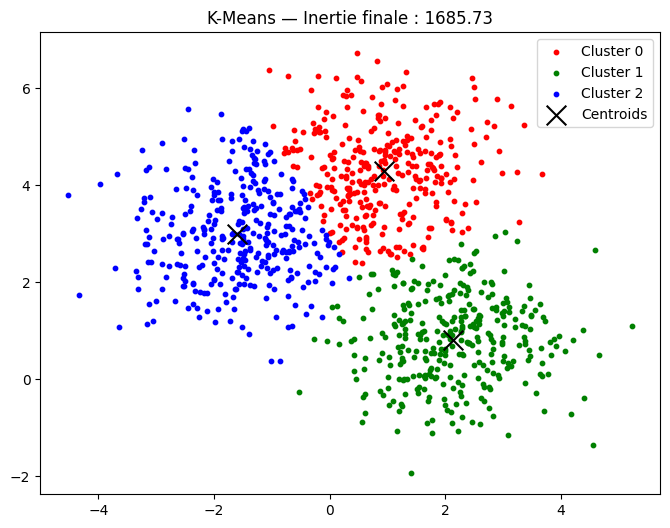

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
for k in range(3):
    pts = X[labels == k]
    plt.scatter(pts[:, 0], pts[:, 1], c=color[k], s=10, label=f'Cluster {k}')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=200, label='Centroids')
plt.legend()
plt.title(f'K-Means — Inertie finale : {inertia:.2f}')
plt.show()

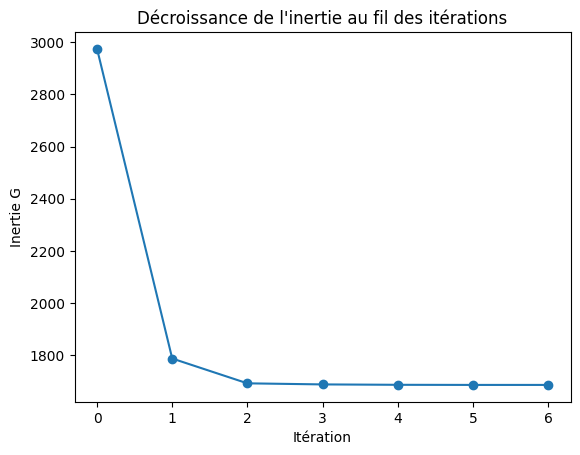

In [17]:
def kmeans_with_history(X, n_clusters, max_iter=100, tol=1e-7, random_state=42):
    rng = np.random.RandomState(random_state)
    idx = rng.choice(X.shape[0], n_clusters, replace=False)
    centroids = X[idx].copy()
    inertia_history = []
    inertia = np.inf

    for _ in range(max_iter):
        labels = compute_labels(X, centroids)
        new_inertia, new_centroids = compute_inertia_centroids(X, labels)
        inertia_history.append(new_inertia)

        if abs(inertia - new_inertia) < tol:
            break
        inertia = new_inertia
        centroids = new_centroids

    return centroids, labels, inertia_history

# Affichage
_, _, history = kmeans_with_history(X, n_clusters=3)
plt.plot(history, marker='o')
plt.xlabel('Itération')
plt.ylabel('Inertie G')
plt.title('Décroissance de l\'inertie au fil des itérations')
plt.show()

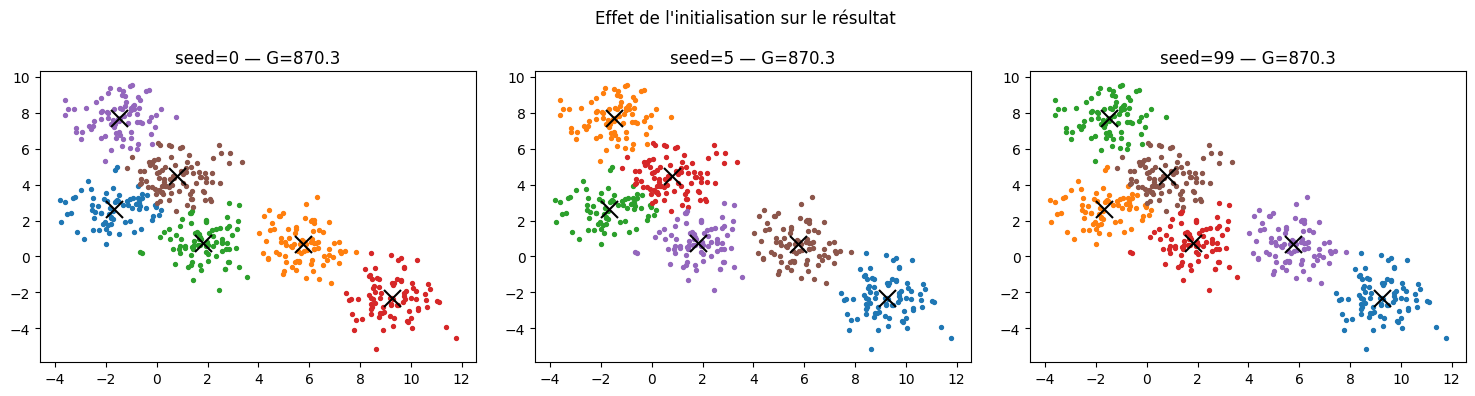

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Générer des données avec plus de clusters pour mieux voir l'effet
X6, _ = make_blobs(n_samples=500, random_state=0, centers=6)

for i, seed in enumerate([0, 5, 99]):
    centroids, labels, inertia = kmeans(X6, n_clusters=6, random_state=seed)
    ax = axes[i]
    for k in range(6):
        pts = X6[labels == k]
        ax.scatter(pts[:, 0], pts[:, 1], s=8)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=150)
    ax.set_title(f'seed={seed} — G={inertia:.1f}')

plt.suptitle('Effet de l\'initialisation sur le résultat')
plt.tight_layout()
plt.show()

In [19]:
import time
from sklearn import cluster

# Ton implémentation
t0 = time.time()
c_mine, l_mine, iner_mine = kmeans(X, n_clusters=3, random_state=42)
t_mine = time.time() - t0

# sklearn
t0 = time.time()
km_sk = cluster.KMeans(n_clusters=3, n_init=10, random_state=42)
km_sk.fit(X)
t_sk = time.time() - t0

print(f"Ton impl. — inertie : {iner_mine:.2f} — temps : {t_mine*1000:.1f} ms")
print(f"sklearn   — inertie : {km_sk.inertia_:.2f} — temps : {t_sk*1000:.1f} ms")

Ton impl. — inertie : 1685.73 — temps : 2.0 ms
sklearn   — inertie : 1685.73 — temps : 1782.0 ms


### Optimal Calculation of the Number of Clusters

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

### Q1

In [21]:
def compute_log_inertia(X, n_clusters, T, bb_min, bb_max,
                        random_state=0):
    """Compute the log inertia of X and X_t.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_clusters: int
        The desired number of clusters.

    T: int
        Number of draws of X_t.

    bb_min: array, shape (n_features,)
        Inferior corner of the bounding box of X.

    bb_max: array, shape (n_features,)
        Superior corner of the bounding box of X.

    random_state: int, defaults to 0.
        A random number generator instance.

    Returns
    -------
    log_inertia: float
        Log of the inertia of the K-means applied to X.

    mean_log_inertia_rand: float
        Mean of the log of the inertia of the K-means applied to the different
        X_t.

    std_log_inertia_rand: float
        Standard deviation of the log of the inertia of the K-means applied to
        the different X_t.
    """
    # Inertie sur les données réelles
    _, _, inertia_X = kmeans(X, n_clusters, random_state=random_state)
    log_inertia = np.log(inertia_X)
    
    # T tirages aléatoires uniformes dans la bounding box
    rng = np.random.RandomState(random_state)
    log_inertias_rand = []
    
    for t in range(T):
        # Tirage uniforme dans [bb_min, bb_max]
        X_t = rng.uniform(bb_min, bb_max, size=X.shape)
        _, _, inertia_t = kmeans(X_t, n_clusters, random_state=t)
        log_inertias_rand.append(np.log(inertia_t))
    
    mean_log = np.mean(log_inertias_rand)
    std_log  = np.std(log_inertias_rand)
    
    return log_inertia, mean_log, std_log

### Q2

In [22]:
def compute_gap(X, n_clusters_max, T=10, random_state=0):
    """Compute values of Gap and delta.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_cluster_max: int
        Maximum number of cluster to test.

    T: int, defaults 10.
        Number of draws of X_t.

    random_state: int, defaults to 0.
        A random number generator instance.

    Returns
    -------
    n_clusters_range: array-like, shape (n_clusters_max-1,)
        Array of number of clusters tested.

    gap: array-like, shape (n_clusters_max-1,)
        Return the gap values.

    delta: array-like, shape (n_clusters_max-1,)
        Return the delta values.
    """
    bb_min = X.min(axis=0)
    bb_max = X.max(axis=0)
    
    n_clusters_range = range(1, n_clusters_max)  # k de 1 à n_clusters_max - 1
    gap_values   = []
    delta_values = []
    log_iner_list = []
    mean_list    = []
    sigma_list   = []
    
    for k in n_clusters_range:
        log_iner, mean_log, std_log = compute_log_inertia(
            X, k, T, bb_min, bb_max, random_state
        )
        # σ(k) = sqrt((T+1)/T) * std
        sigma_k = np.sqrt((T + 1) / T) * std_log
        
        gap_values.append(mean_log - log_iner)
        sigma_list.append(sigma_k)
    
    # Calcul de δ(k) = Gap(k) - (Gap(k+1) - σ(k+1))
    for i in range(len(gap_values) - 1):
        delta_k = gap_values[i] - (gap_values[i+1] - sigma_list[i+1])
        delta_values.append(delta_k)
    delta_values.append(np.nan)  # pas de δ pour le dernier k
    
    return list(n_clusters_range), gap_values, delta_values


### Q4

Nombre optimal de clusters : 2
Vraie valeur : 2 — Trouvé : 2
Nombre optimal de clusters : 3
Vraie valeur : 3 — Trouvé : 3
Nombre optimal de clusters : 5
Vraie valeur : 5 — Trouvé : 5


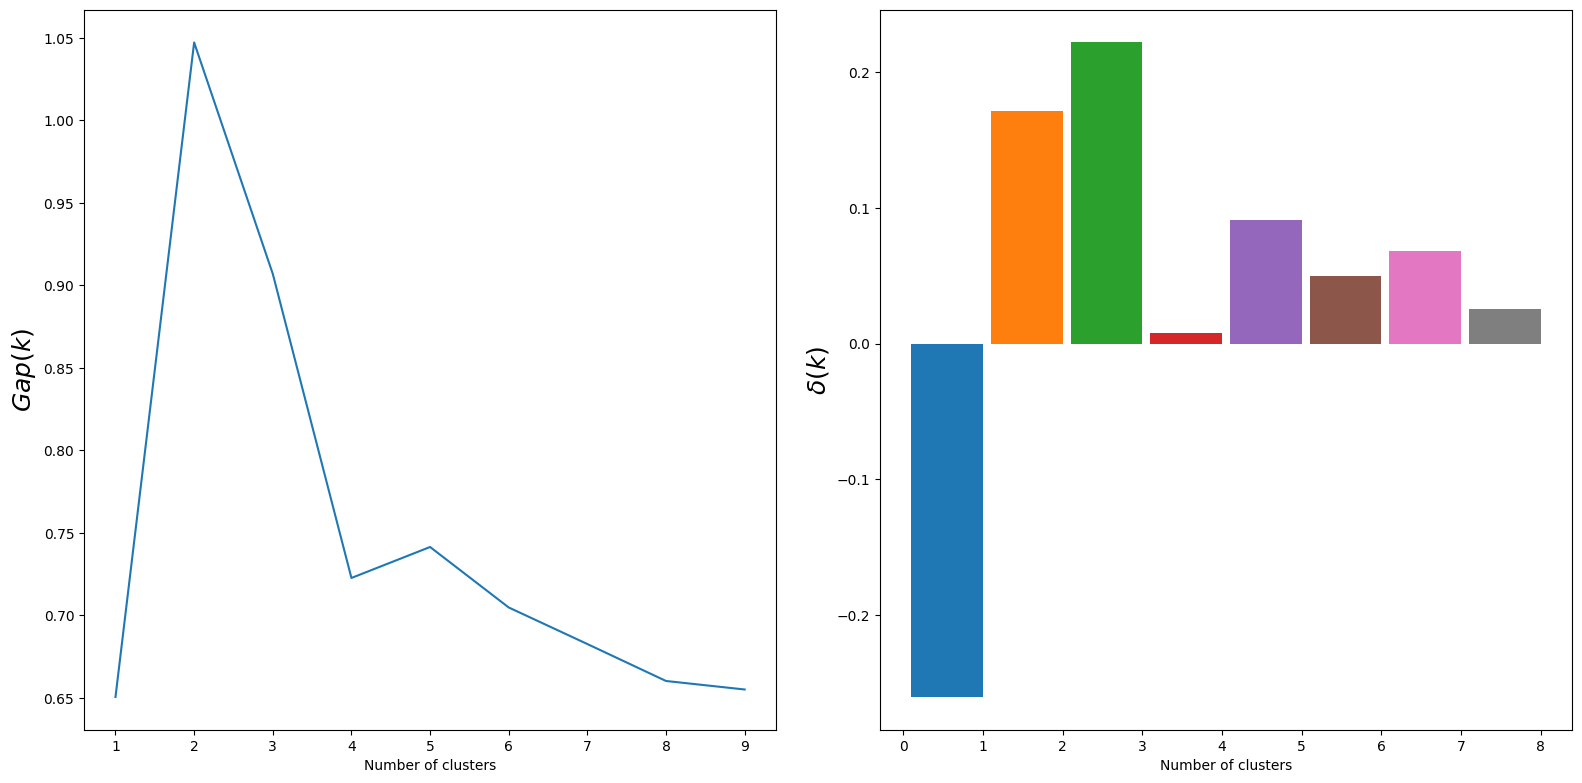

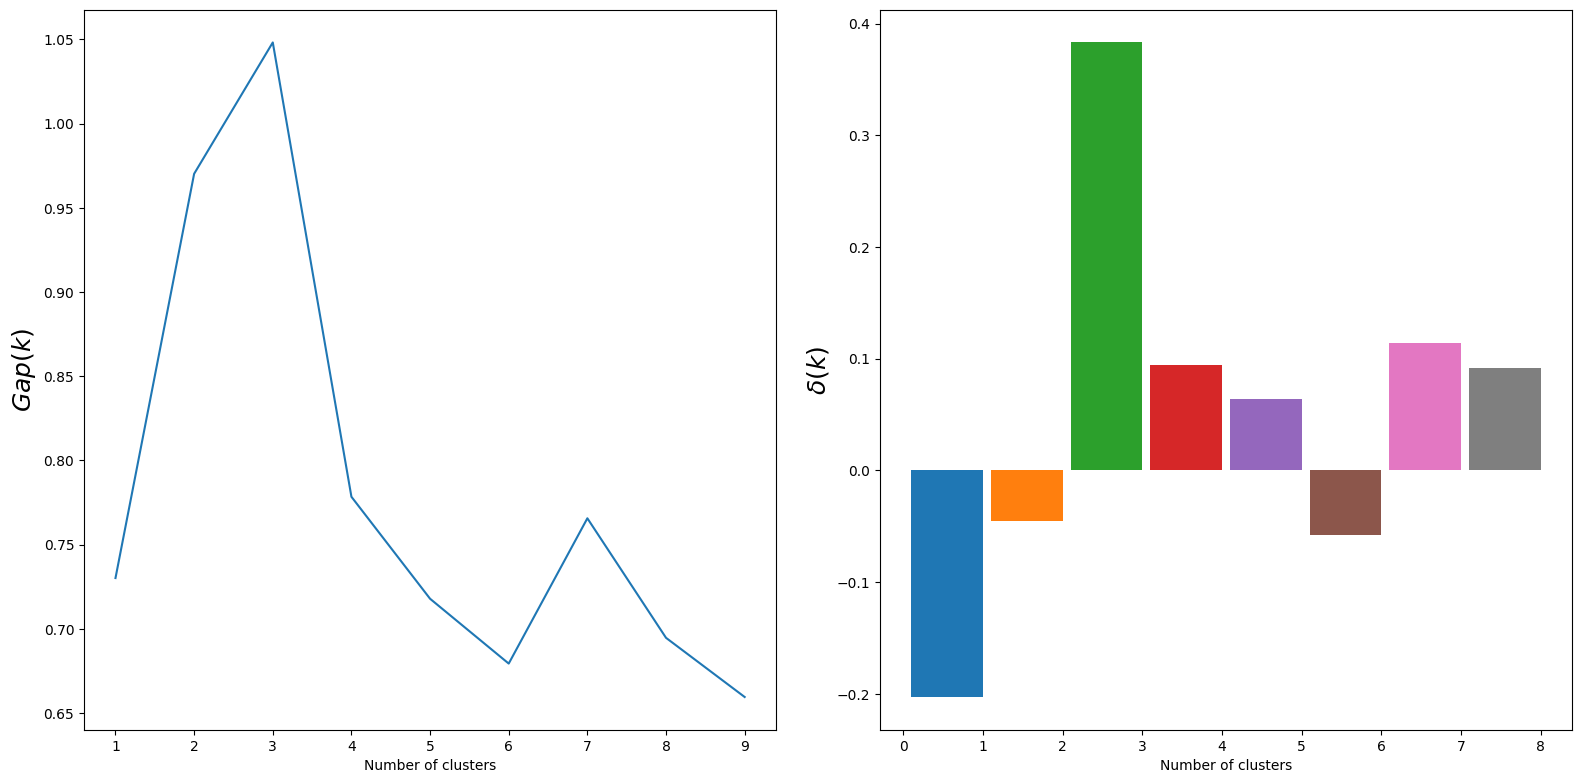

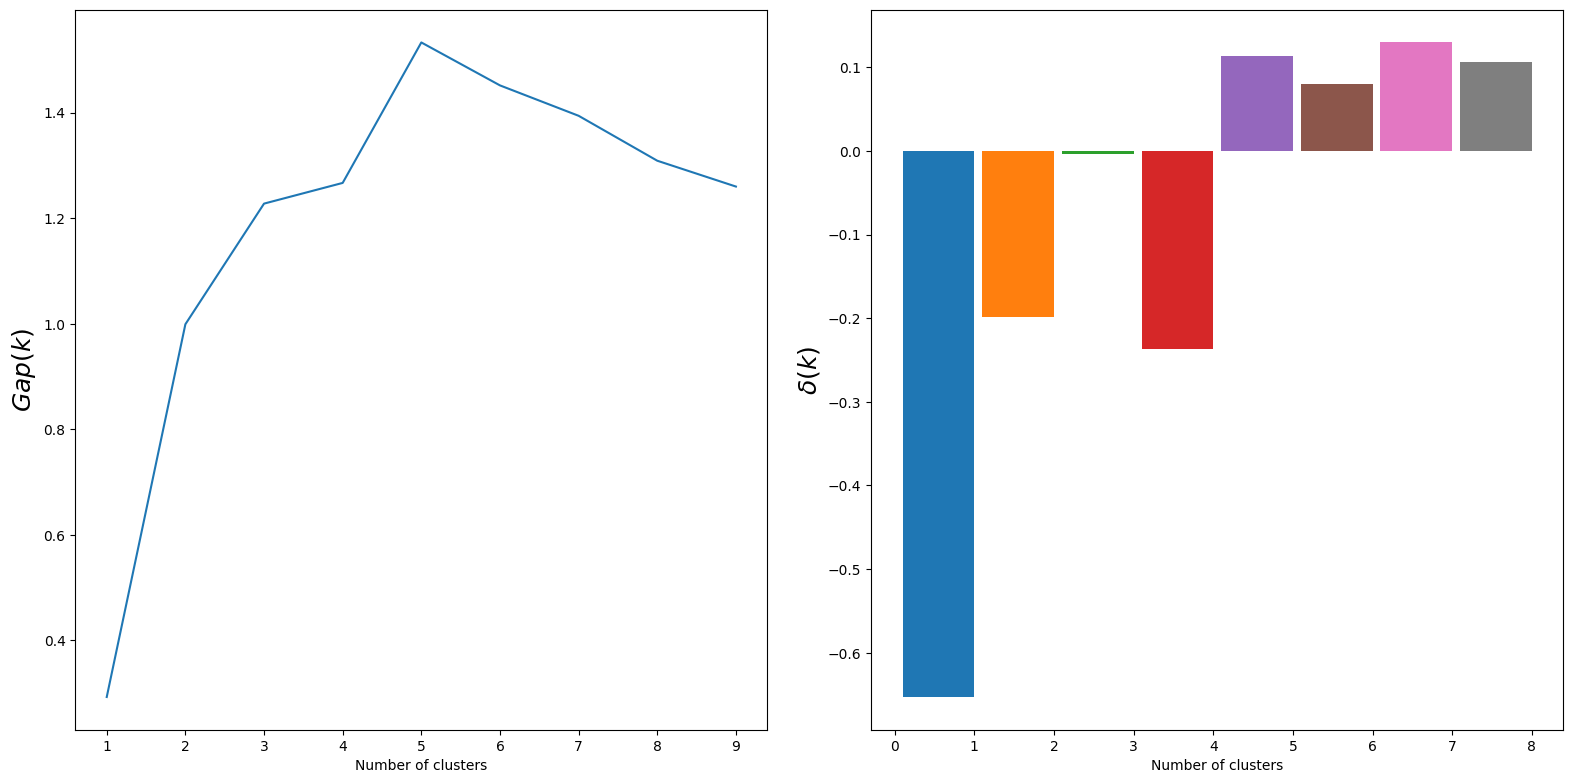

In [24]:
def plot_result(n_clusters_range, gap, delta):
    """Plot the values of Gap and delta.

    Parameters
    ----------
    n_clusters_range: array-like, shape (n_clusters_max-1,)
        Array of number of clusters tested.

    gap: array-like, shape (n_clusters_max-1,)
        Return the gap values.

    delta: array-like, shape (n_clusters_max-1,)
        Return the delta values.
    """
    plt.figure(figsize=(16, 8))
    plt.subplots_adjust(left=.05, right=.98, bottom=.08, top=.98, wspace=.15,
                        hspace=.03)

    plt.subplot(121)
    plt.plot(n_clusters_range, gap)
    plt.ylabel(r'$Gap(k)$', fontsize=18)
    plt.xlabel("Number of clusters")

    plt.subplot(122)
    for x, y in zip(n_clusters_range, delta):
        plt.bar(x - .45, y, width=0.9)
    plt.ylabel(r'$\delta(k)$', fontsize=18)
    plt.xlabel("Number of clusters")

    plt.draw()


def optimal_n_clusters_search(X, n_clusters_max, T=10, random_state=0):
    """Compute the optimal number of clusters.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_cluster_max: int
        Maximum number of cluster to test.

    T: int, defaults 10.
        Number of draws of X_t.

    random_state: int, defaults to 0.
        A random number generator instance.

    Returns
    -------
    n_clusters_optimal: int
        Optimal number of clusters.
    """
    n_clusters_range, gap, delta = compute_gap(
        X, n_clusters_max, T, random_state
    )
    
    # K* = premier k où δ(k) >= 0
    for i, (k, d) in enumerate(zip(n_clusters_range, delta)):
        if d is not np.nan and not np.isnan(d) and d >= 0:
            optimal_k = k
            break
    else:
        optimal_k = n_clusters_range[-1]
    
    plot_result(n_clusters_range, gap, delta)
    print(f"Nombre optimal de clusters : {optimal_k}")
    return optimal_k

# Test sur plusieurs jeux de données
for n_centers in [2, 3, 5]:
    X_test, _ = make_blobs(n_samples=500, centers=n_centers, random_state=0)
    k_opt = optimal_n_clusters_search(X_test, n_clusters_max=10)
    print(f"Vraie valeur : {n_centers} — Trouvé : {k_opt}")

In [25]:
if __name__ == '__main__':
    # Parameters
    random_state = 0
    n_samples, n_clusters_max = 1000, 10